# ScribeCheck

**Author:** Shivanshu Ade  
**Deliverable 3**:  Deep Learning Semester Project, Spring 2026 

---

**Note**: D2 refers to Deliverable two and D3 refers to all the work I have done for Project Deliverable 3

---
## 1. Environment Setup

In [1]:
import sys, os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from jiwer import cer, wer
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

PROJECT_ROOT = os.path.abspath('..')
sys.path.insert(0, PROJECT_ROOT)

# Handle flat vs src/ structure
if not os.path.exists(os.path.join(PROJECT_ROOT, 'src')):
    import types
    src_module = types.ModuleType('src')
    src_module.__path__ = [PROJECT_ROOT]
    sys.modules['src'] = src_module
    print('Note: Using flat file structure.')

RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Python:  {sys.version.split()[0]}')
print(f'PyTorch: {torch.__version__}')
print(f'Device:  {device}')
print('Environment ready.')

Python:  3.10.19
PyTorch: 2.5.1
Device:  mps
Environment ready.


---
## 2. Load Dataset & Model

In [2]:
print('Loading IAM dataset...')
full_dataset = load_dataset('Teklia/IAM-line', split='train')
full_dataset = full_dataset.shuffle(seed=42)

# D3: Expanded to 200 test samples (D2 used 50)
NUM_TEST_D3 = 200
NUM_TEST_D2 = 50

test_data_d3 = full_dataset.select(range(NUM_TEST_D3))
test_data_d2 = full_dataset.select(range(NUM_TEST_D2))  # Same first 50 for fair comparison

print(f'Total dataset: {len(full_dataset)}')
print(f'D2 test set: {NUM_TEST_D2} samples')
print(f'D3 test set: {NUM_TEST_D3} samples (4x expansion)')

Loading IAM dataset...


Total dataset: 6482
D2 test set: 50 samples
D3 test set: 200 samples (4x expansion)


In [3]:
MODEL_NAME = 'microsoft/trocr-base-handwritten'
print(f'Loading {MODEL_NAME}...')
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME).to(device)
model.eval()
print(f'Model loaded on {device} | {sum(p.numel() for p in model.parameters()):,} parameters')

Loading microsoft/trocr-base-handwritten...


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on mps | 333,921,792 parameters


---
## 3. Preprocessing Comparison — D2 vs D3

**D2 pipeline:** Grayscale → Denoise → Otsu binarization → Deskew  
**D3 pipeline:** Grayscale → CLAHE contrast enhancement → Denoise → Adaptive binarization → Deskew

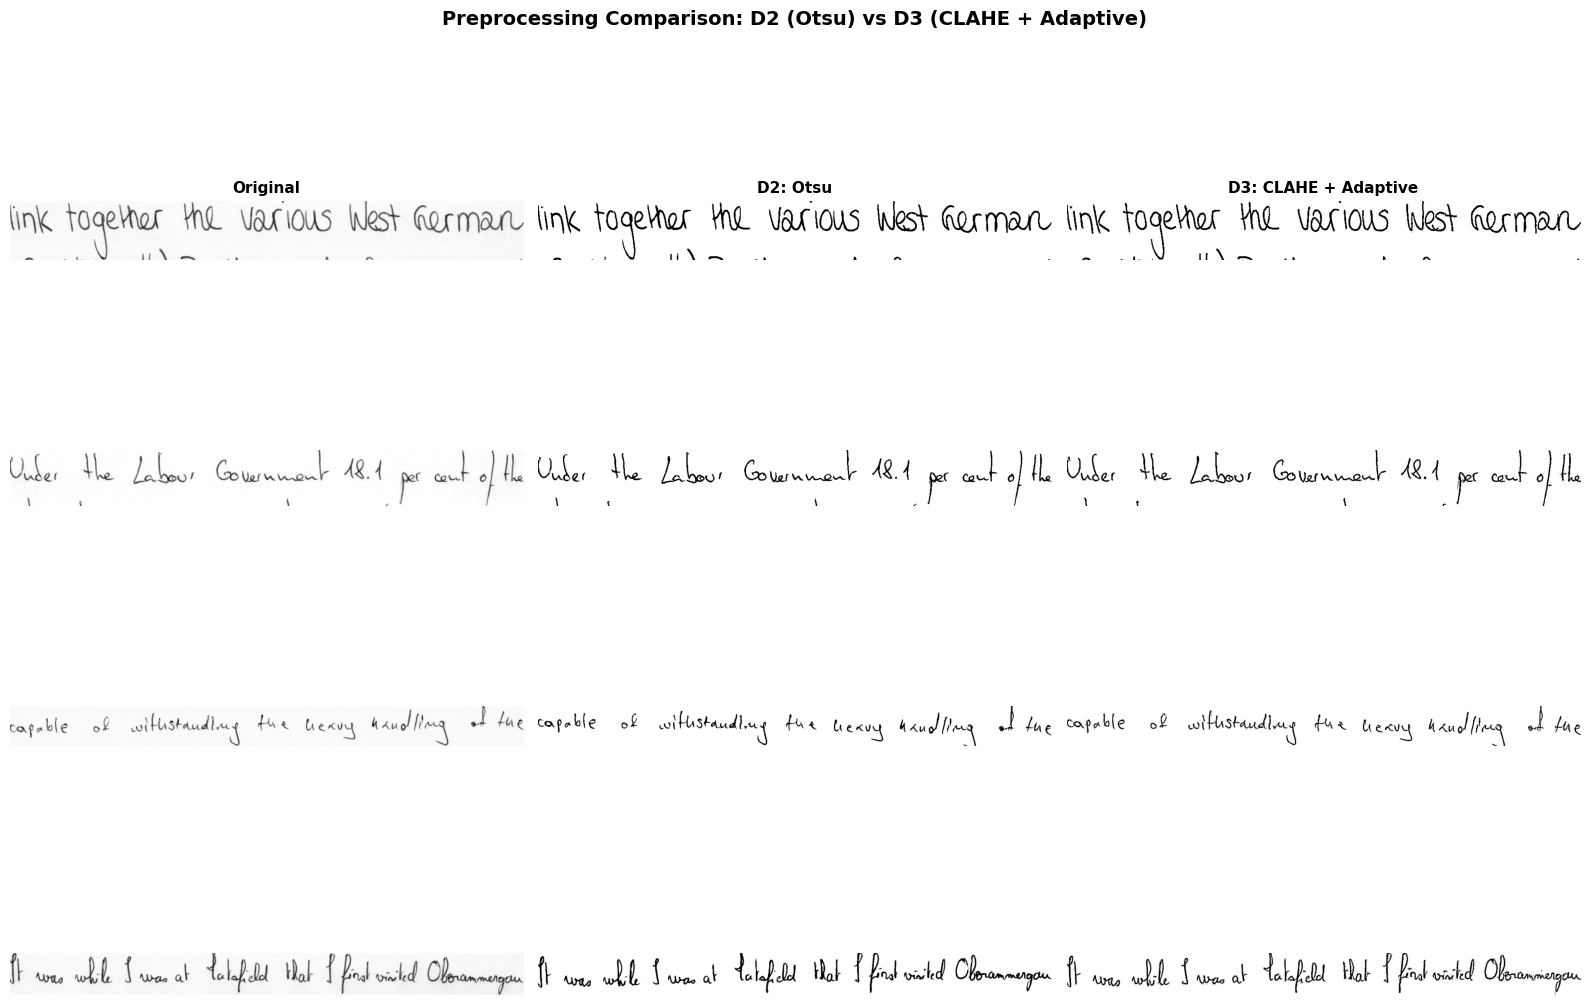

D3 preprocessing uses CLAHE for better contrast and adaptive thresholding for varied lighting.


In [4]:
from src.preprocessing import preprocess_comparison, assess_image_quality, pil_to_cv2

# Compare preprocessing on several samples
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
fig.suptitle('Preprocessing Comparison: D2 (Otsu) vs D3 (CLAHE + Adaptive)', fontsize=14, fontweight='bold')
col_titles = ['Original', 'D2: Otsu', 'D3: CLAHE + Adaptive']

for row in range(4):
    sample = test_data_d3[row * 10]
    cv2_img = pil_to_cv2(sample['image'])
    comparison = preprocess_comparison(cv2_img)
    
    for col, (key, title) in enumerate(zip(['original', 'd2_preprocessed', 'd3_preprocessed'], col_titles)):
        axes[row, col].imshow(comparison[key], cmap='gray')
        if row == 0:
            axes[row, col].set_title(title, fontsize=11, fontweight='bold')
        axes[row, col].axis('off')
    
    # Add text label on left
    label = sample['text'][:30] + '...' if len(sample['text']) > 30 else sample['text']
    axes[row, 0].set_ylabel(f'"{label}"', fontsize=8, rotation=0, labelpad=120, va='center')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'preprocessing_comparison_d2_vs_d3.png'), dpi=150, bbox_inches='tight')
plt.show()
print('D3 preprocessing uses CLAHE for better contrast and adaptive thresholding for varied lighting.')

---
## 4. Extended OCR Evaluation — 200 Samples

In [5]:
# Run inference on full D3 test set (200 samples)
model.eval()
predictions_d3, references_d3 = [], []

print(f'Running inference on {NUM_TEST_D3} samples...')
for i in tqdm(range(NUM_TEST_D3)):
    sample = test_data_d3[i]
    image = sample['image'].convert('RGB')
    pv = processor(images=image, return_tensors='pt').pixel_values.to(device)
    with torch.no_grad():
        ids = model.generate(pv, max_length=128)
    predictions_d3.append(processor.batch_decode(ids, skip_special_tokens=True)[0])
    references_d3.append(sample['text'])

# D2 results are the first 50 of D3
predictions_d2 = predictions_d3[:NUM_TEST_D2]
references_d2 = references_d3[:NUM_TEST_D2]

print('Inference complete.')

Running inference on 200 samples...


100%|██████████| 200/200 [01:42<00:00,  1.94it/s]

Inference complete.


In [6]:
from src.evaluation import evaluate_ocr_batch

# Evaluate both sets
ocr_d2 = evaluate_ocr_batch(predictions_d2, references_d2)
ocr_d3 = evaluate_ocr_batch(predictions_d3, references_d3)

cer_d2 = [r['cer'] for r in ocr_d2['per_sample']]
wer_d2 = [r['wer'] for r in ocr_d2['per_sample']]
cer_d3 = [r['cer'] for r in ocr_d3['per_sample']]
wer_d3 = [r['wer'] for r in ocr_d3['per_sample']]

print('=' * 70)
print('OCR EVALUATION: D2 vs D3 COMPARISON')
print('=' * 70)
print(f'{"Metric":<20} {"D2 (50 samples)":>18} {"D3 (200 samples)":>18}')
print('-' * 70)
print(f'{"Mean CER":<20} {ocr_d2["mean_cer"]:.4f} ({ocr_d2["mean_cer"]*100:.2f}%) {ocr_d3["mean_cer"]:.4f} ({ocr_d3["mean_cer"]*100:.2f}%)')
print(f'{"Mean WER":<20} {ocr_d2["mean_wer"]:.4f} ({ocr_d2["mean_wer"]*100:.2f}%) {ocr_d3["mean_wer"]:.4f} ({ocr_d3["mean_wer"]*100:.2f}%)')
print(f'{"Samples":<20} {NUM_TEST_D2:>18} {NUM_TEST_D3:>18}')
print(f'{"Perfect (CER=0)":<20} {sum(1 for c in cer_d2 if c == 0):>18} {sum(1 for c in cer_d3 if c == 0):>18}')
print(f'{"Baseline":<20} {"~4.4% CER":>18} {"~4.4% CER":>18}')

OCR EVALUATION: D2 vs D3 COMPARISON
Metric                  D2 (50 samples)   D3 (200 samples)
----------------------------------------------------------------------
Mean CER             0.0072 (0.72%) 0.0070 (0.70%)
Mean WER             0.0244 (2.44%) 0.0249 (2.49%)
Samples                              50                200
Perfect (CER=0)                      43                175
Baseline                      ~4.4% CER          ~4.4% CER


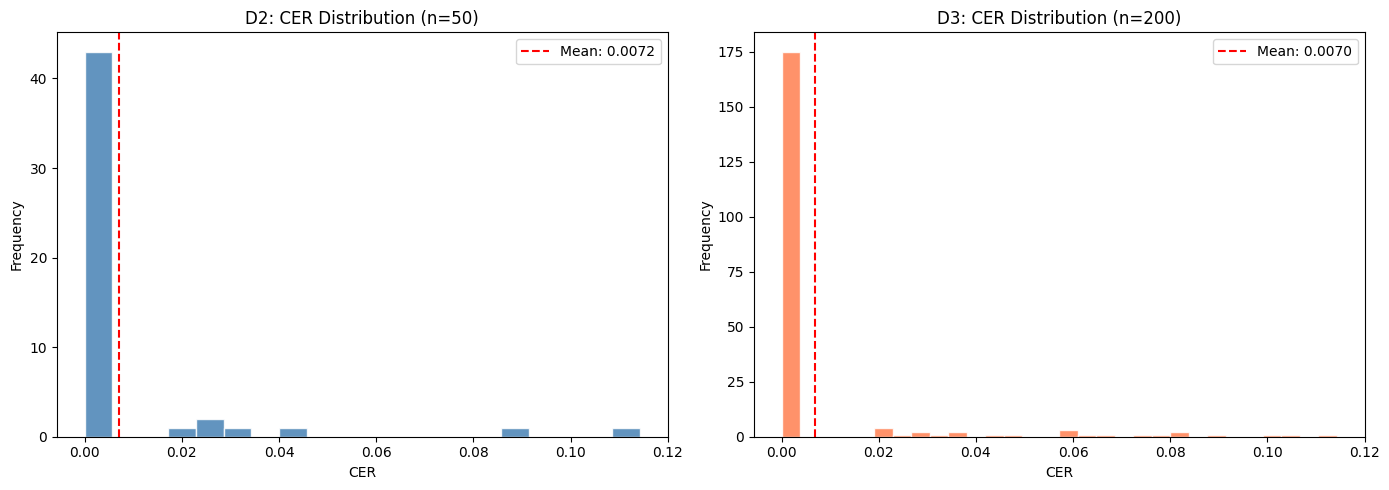

In [7]:
# Side-by-side CER distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cer_d2, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(np.mean(cer_d2), color='red', linestyle='--', label=f'Mean: {np.mean(cer_d2):.4f}')
axes[0].set_xlabel('CER'); axes[0].set_ylabel('Frequency')
axes[0].set_title(f'D2: CER Distribution (n={NUM_TEST_D2})'); axes[0].legend()

axes[1].hist(cer_d3, bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].axvline(np.mean(cer_d3), color='red', linestyle='--', label=f'Mean: {np.mean(cer_d3):.4f}')
axes[1].set_xlabel('CER'); axes[1].set_ylabel('Frequency')
axes[1].set_title(f'D3: CER Distribution (n={NUM_TEST_D3})'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cer_distribution_d2_vs_d3.png'), dpi=150, bbox_inches='tight')
plt.show()

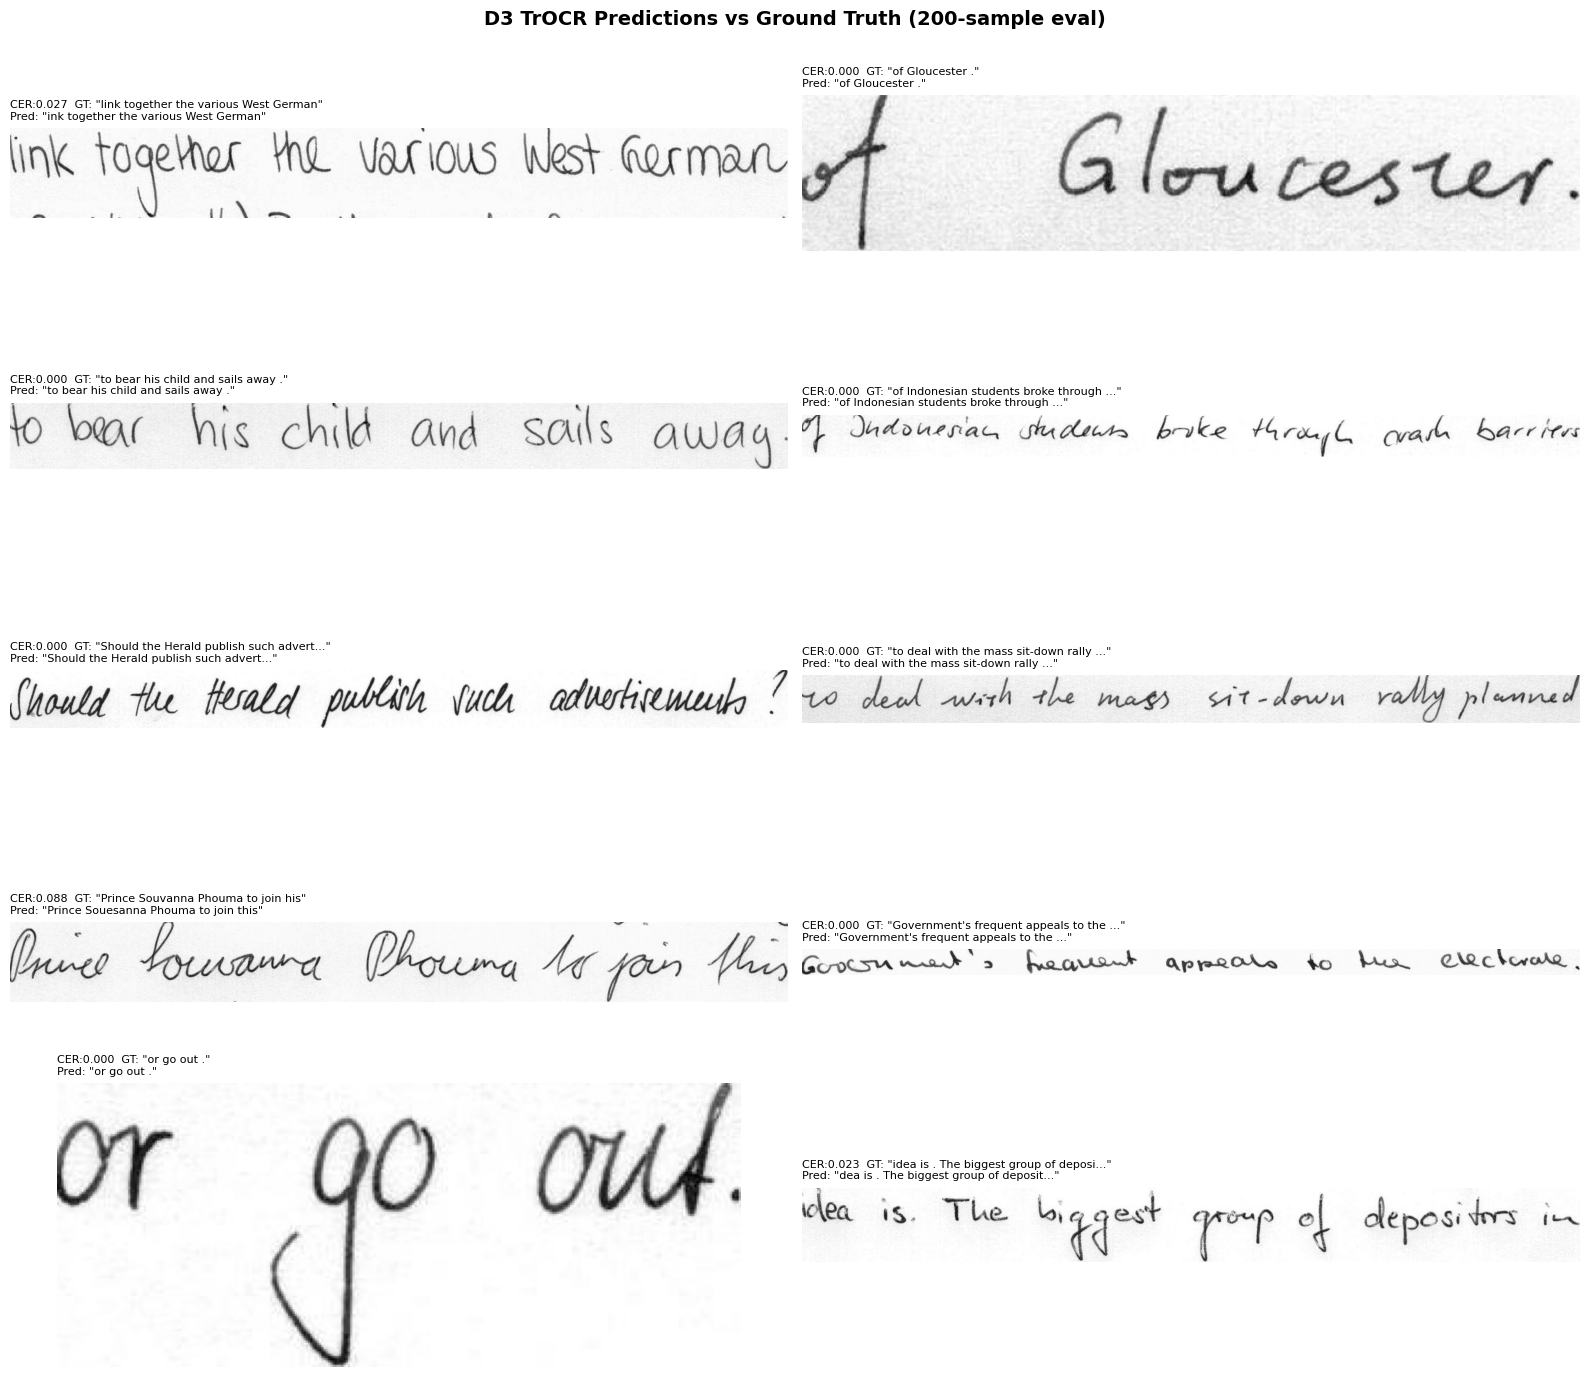

In [8]:
# Predictions vs images for D3
fig, axes = plt.subplots(5, 2, figsize=(16, 14))
fig.suptitle('D3 TrOCR Predictions vs Ground Truth (200-sample eval)', fontsize=14, fontweight='bold')
for idx in range(10):
    row, col = idx // 2, idx % 2
    ax = axes[row, col]
    ax.imshow(test_data_d3[idx]['image'], cmap='gray')
    gt_s = references_d3[idx] if len(references_d3[idx]) <= 40 else references_d3[idx][:37] + '...'
    pr_s = predictions_d3[idx] if len(predictions_d3[idx]) <= 40 else predictions_d3[idx][:37] + '...'
    ax.set_title(f'CER:{cer_d3[idx]:.3f}  GT: "{gt_s}"\nPred: "{pr_s}"', fontsize=8, ha='left', x=0)
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'test_predictions_d3.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Extended Similarity Scoring

In [9]:
from src.similarity import compute_hybrid_score

print('Computing similarity scores on D3 test set (200 samples)...')
sim_d3 = [compute_hybrid_score(p, r, return_breakdown=True) for p, r in zip(predictions_d3, references_d3)]

# Also compute D2 for comparison
sim_d2 = sim_d3[:NUM_TEST_D2]

df_d3 = pd.DataFrame({
    'reference': references_d3, 'prediction': predictions_d3,
    'cer': cer_d3, 'wer': wer_d3,
    'levenshtein': [s['levenshtein'] for s in sim_d3],
    'bleu': [s['bleu'] for s in sim_d3],
    'cosine': [s['cosine'] for s in sim_d3],
    'combined': [s['combined_score'] for s in sim_d3],
    'text_length': [len(r) for r in references_d3],
})

df_d2 = df_d3.iloc[:NUM_TEST_D2].copy()

print('\nSIMILARITY COMPARISON: D2 vs D3')
print('=' * 60)
print(f'{"Metric":<20} {"D2 (50)":>12} {"D3 (200)":>12}')
print('-' * 60)
for col in ['levenshtein', 'bleu', 'cosine', 'combined']:
    print(f'{col:<20} {df_d2[col].mean():>12.4f} {df_d3[col].mean():>12.4f}')

Computing similarity scores on D3 test set (200 samples)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded sentence-transformers: all-MiniLM-L6-v2

SIMILARITY COMPARISON: D2 vs D3
Metric                    D2 (50)     D3 (200)
------------------------------------------------------------
levenshtein                0.9931       0.9931
bleu                       0.9273       0.9403
cosine                     0.9778       0.9832
combined                   0.9680       0.9738


In [10]:
# Full D3 summary statistics
print('\nD3 FULL SIMILARITY SUMMARY (200 samples)')
print('=' * 60)
print(df_d3[['cer','wer','levenshtein','bleu','cosine','combined']].describe().round(4).to_string())


D3 FULL SIMILARITY SUMMARY (200 samples)
            cer       wer  levenshtein      bleu    cosine  combined
count  200.0000  200.0000     200.0000  200.0000  200.0000  200.0000
mean     0.0070    0.0249       0.9931    0.9403    0.9832    0.9738
std      0.0211    0.0731       0.0207    0.1800    0.0644    0.0763
min      0.0000    0.0000       0.8919    0.1221    0.6151    0.6095
25%      0.0000    0.0000       1.0000    1.0000    1.0000    1.0000
50%      0.0000    0.0000       1.0000    1.0000    1.0000    1.0000
75%      0.0000    0.0000       1.0000    1.0000    1.0000    1.0000
max      0.1143    0.3529       1.0000    1.0000    1.0000    1.0000


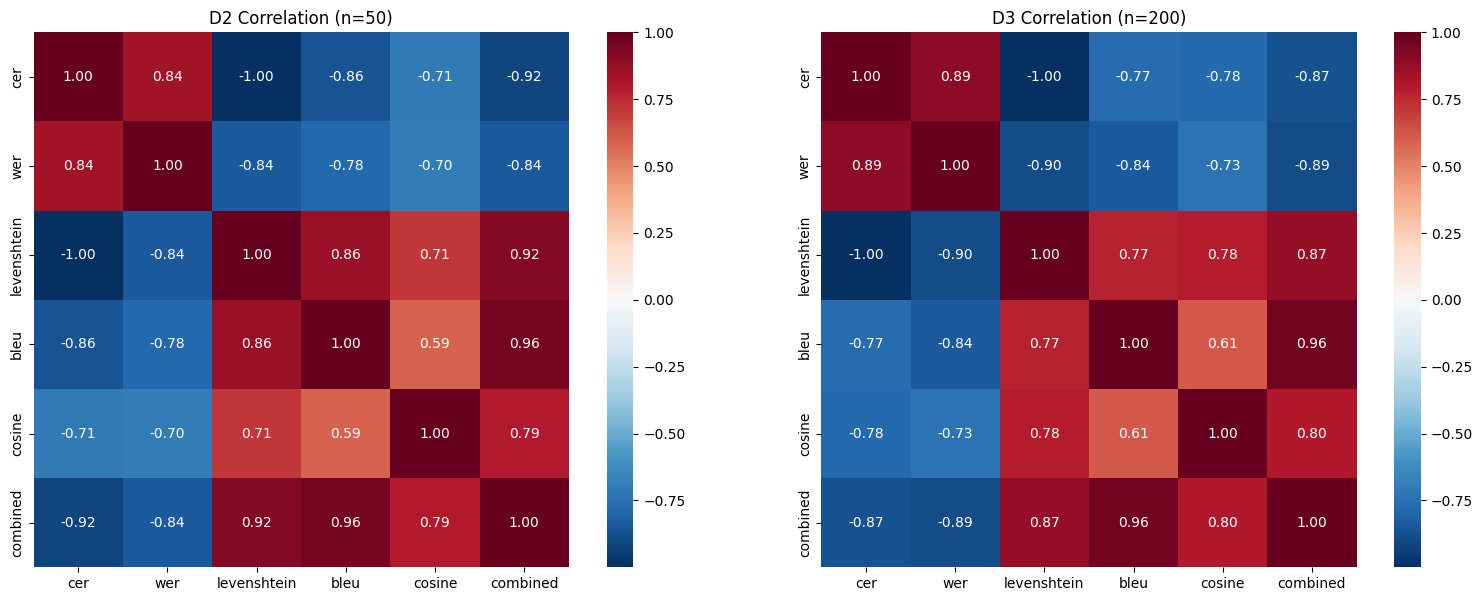

In [11]:
# Updated correlation heatmap (D3)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_d2 = df_d2[['cer','wer','levenshtein','bleu','cosine','combined']].corr()
sns.heatmap(corr_d2, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[0], square=True)
axes[0].set_title(f'D2 Correlation (n={NUM_TEST_D2})')

corr_d3 = df_d3[['cer','wer','levenshtein','bleu','cosine','combined']].corr()
sns.heatmap(corr_d3, annot=True, cmap='RdBu_r', center=0, fmt='.2f', ax=axes[1], square=True)
axes[1].set_title(f'D3 Correlation (n={NUM_TEST_D3})')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'correlation_d2_vs_d3.png'), dpi=150, bbox_inches='tight')
plt.show()

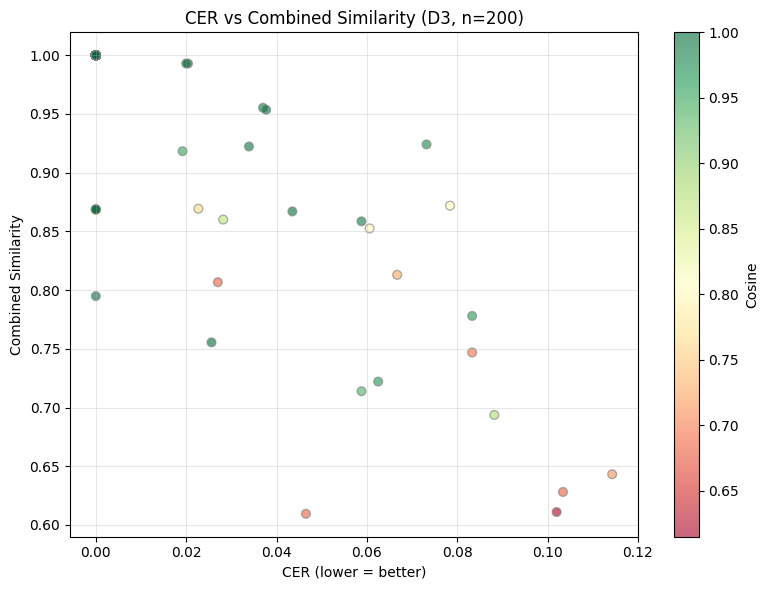

In [12]:
# CER vs Similarity scatter (D3)
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df_d3['cer'], df_d3['combined'], c=df_d3['cosine'], cmap='RdYlGn', alpha=0.6, edgecolors='gray', s=40)
ax.set_xlabel('CER (lower = better)'); ax.set_ylabel('Combined Similarity')
ax.set_title(f'CER vs Combined Similarity (D3, n={NUM_TEST_D3})'); plt.colorbar(sc, label='Cosine'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cer_vs_similarity_d3.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Cascade Failure Analysis (D3 — Extended)

In [13]:
from src.evaluation import cascade_analysis

cascade_d2 = cascade_analysis(predictions_d2, references_d2, cer_threshold=0.1)
cascade_d3 = cascade_analysis(predictions_d3, references_d3, cer_threshold=0.1)

print('CASCADE ANALYSIS COMPARISON')
print('=' * 70)
print(f'{"":<25} {"D2 (50 samples)":>20} {"D3 (200 samples)":>20}')
print('-' * 70)
print(f'{"Good OCR count":<25} {cascade_d2["good_ocr"]["count"]:>20} {cascade_d3["good_ocr"]["count"]:>20}')
print(f'{"Poor OCR count":<25} {cascade_d2["poor_ocr"]["count"]:>20} {cascade_d3["poor_ocr"]["count"]:>20}')

if cascade_d3['good_ocr']['count'] > 0:
    g = cascade_d3['good_ocr']
    print(f'\nD3 Good OCR (CER <= 0.1): n={g["count"]}')
    print(f'  Mean CER: {g["mean_cer"]:.4f}, Combined: {g["mean_combined"]:.4f}')
    print(f'  Lev: {g["mean_levenshtein"]:.4f}, BLEU: {g["mean_bleu"]:.4f}, Cos: {g["mean_cosine"]:.4f}')

if cascade_d3['poor_ocr']['count'] > 0:
    p = cascade_d3['poor_ocr']
    print(f'\nD3 Poor OCR (CER > 0.1): n={p["count"]}')
    print(f'  Mean CER: {p["mean_cer"]:.4f}, Combined: {p["mean_combined"]:.4f}')
    print(f'  Lev: {p["mean_levenshtein"]:.4f}, BLEU: {p["mean_bleu"]:.4f}, Cos: {p["mean_cosine"]:.4f}')

print(f'\nWith 200 samples, we now have {cascade_d3["poor_ocr"]["count"]} poor-OCR samples')
print(f'(vs {cascade_d2["poor_ocr"]["count"]} in D2), enabling more robust cascade analysis.')

CASCADE ANALYSIS COMPARISON
                               D2 (50 samples)     D3 (200 samples)
----------------------------------------------------------------------
Good OCR count                              49                  197
Poor OCR count                               1                    3

D3 Good OCR (CER <= 0.1): n=197
  Mean CER: 0.0055, Combined: 0.9791
  Lev: 0.9946, BLEU: 0.9506, Cos: 0.9880

D3 Poor OCR (CER > 0.1): n=3
  Mean CER: 0.1066, Combined: 0.6274
  Lev: 0.8955, BLEU: 0.2669, Cos: 0.6685

With 200 samples, we now have 3 poor-OCR samples
(vs 1 in D2), enabling more robust cascade analysis.


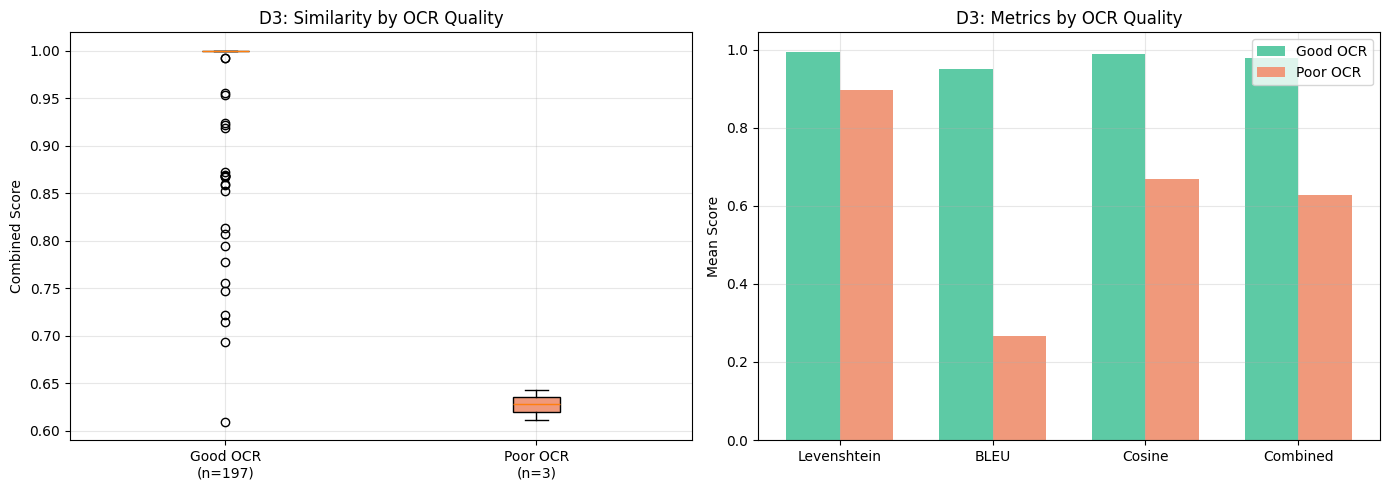

In [14]:
# Cascade visualization (D3)
good_c = [s['combined_score'] for s in cascade_d3['good_ocr_samples']]
poor_c = [s['combined_score'] for s in cascade_d3['poor_ocr_samples']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_box, labels_box = [], []
if good_c: data_box.append(good_c); labels_box.append(f'Good OCR\n(n={len(good_c)})')
if poor_c: data_box.append(poor_c); labels_box.append(f'Poor OCR\n(n={len(poor_c)})')
if data_box:
    bp = axes[0].boxplot(data_box, tick_labels=labels_box, patch_artist=True)
    for patch, c in zip(bp['boxes'], ['#5DCAA5','#F0997B']): patch.set_facecolor(c)
axes[0].set_ylabel('Combined Score'); axes[0].set_title('D3: Similarity by OCR Quality'); axes[0].grid(alpha=0.3)

names = ['Levenshtein','BLEU','Cosine','Combined']
keys_ = ['mean_levenshtein','mean_bleu','mean_cosine','mean_combined']
x = np.arange(len(names)); w = 0.35
if cascade_d3['good_ocr']['count'] > 0:
    axes[1].bar(x-w/2, [cascade_d3['good_ocr'].get(k,0) or 0 for k in keys_], w, label='Good OCR', color='#5DCAA5')
if cascade_d3['poor_ocr']['count'] > 0:
    axes[1].bar(x+w/2, [cascade_d3['poor_ocr'].get(k,0) or 0 for k in keys_], w, label='Poor OCR', color='#F0997B')
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_ylabel('Mean Score'); axes[1].set_title('D3: Metrics by OCR Quality'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'cascade_analysis_d3.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Weight Sensitivity Analysis (New in D3)

Analyze how changing the similarity metric weights affects the combined score.

In [15]:
# Test different weight configurations
weight_configs = [
    {'name': 'Equal',             'levenshtein': 0.33, 'bleu': 0.34, 'cosine': 0.33},
    {'name': 'D2 Default',        'levenshtein': 0.35, 'bleu': 0.30, 'cosine': 0.35},
    {'name': 'Character-heavy',   'levenshtein': 0.60, 'bleu': 0.20, 'cosine': 0.20},
    {'name': 'Semantic-heavy',    'levenshtein': 0.20, 'bleu': 0.20, 'cosine': 0.60},
    {'name': 'BLEU-heavy',        'levenshtein': 0.20, 'bleu': 0.60, 'cosine': 0.20},
    {'name': 'Lev+Cos (no BLEU)', 'levenshtein': 0.50, 'bleu': 0.00, 'cosine': 0.50},
]

print('WEIGHT SENSITIVITY ANALYSIS')
print('=' * 70)
print(f'{"Config":<22} {"Weights (L/B/C)":<18} {"Mean Combined":>14} {"Std":>8} {"Min":>8}')
print('-' * 70)

sensitivity_results = []
for cfg in weight_configs:
    w = {k: cfg[k] for k in ['levenshtein', 'bleu', 'cosine']}
    scores = [compute_hybrid_score(p, r, weights=w)['combined_score']
              for p, r in zip(predictions_d3, references_d3)]
    sensitivity_results.append({'name': cfg['name'], 'mean': np.mean(scores), 'std': np.std(scores), 'min': np.min(scores)})
    w_str = f'{cfg["levenshtein"]:.2f}/{cfg["bleu"]:.2f}/{cfg["cosine"]:.2f}'
    print(f'{cfg["name"]:<22} {w_str:<18} {np.mean(scores):>14.4f} {np.std(scores):>8.4f} {np.min(scores):>8.4f}')

print(f'\nThe default weights (0.35/0.30/0.35) provide a balanced trade-off.')
print(f'Character-heavy weights penalize OCR errors more severely.')
print(f'Semantic-heavy weights are more forgiving of character-level errors.')

WEIGHT SENSITIVITY ANALYSIS
Config                 Weights (L/B/C)     Mean Combined      Std      Min
----------------------------------------------------------------------
Equal                  0.33/0.34/0.33             0.9719   0.0817   0.5816
D2 Default             0.35/0.30/0.35             0.9738   0.0761   0.6095
Character-heavy        0.60/0.20/0.20             0.9806   0.0557   0.7161
Semantic-heavy         0.20/0.20/0.60             0.9766   0.0705   0.6030
BLEU-heavy             0.20/0.60/0.20             0.9595   0.1194   0.4006
Lev+Cos (no BLEU)      0.50/0.00/0.50             0.9882   0.0407   0.7565

The default weights (0.35/0.30/0.35) provide a balanced trade-off.
Character-heavy weights penalize OCR errors more severely.
Semantic-heavy weights are more forgiving of character-level errors.


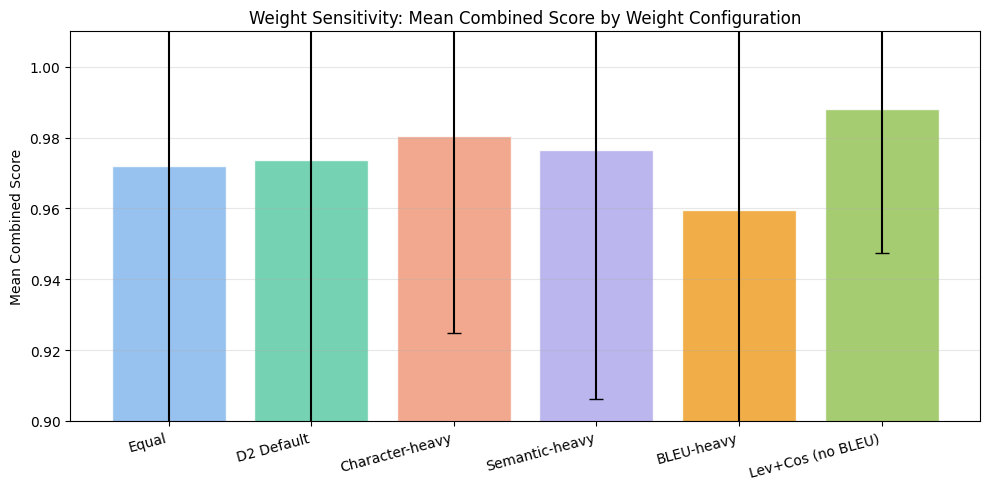

In [16]:
# Visualize weight sensitivity
fig, ax = plt.subplots(figsize=(10, 5))
names = [r['name'] for r in sensitivity_results]
means = [r['mean'] for r in sensitivity_results]
stds = [r['std'] for r in sensitivity_results]

bars = ax.bar(names, means, yerr=stds, capsize=5, color=['#85B7EB','#5DCAA5','#F0997B','#AFA9EC','#EF9F27','#97C459'], edgecolor='white', alpha=0.85)
ax.set_ylabel('Mean Combined Score')
ax.set_title('Weight Sensitivity: Mean Combined Score by Weight Configuration')
ax.set_ylim(0.9, 1.01)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'weight_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Difficulty-Stratified Evaluation (New in D3)

Analyze how text length affects OCR performance.

DIFFICULTY ANALYSIS: Performance by Text Length
                 count  mean_cer  mean_wer  mean_combined
length_bin                                               
Short (<20)          7    0.0173    0.0714         0.8526
Medium (20-40)      66    0.0098    0.0326         0.9641
Long (40-60)       116    0.0052    0.0184         0.9854
Very Long (60+)     11    0.0026    0.0182         0.9873


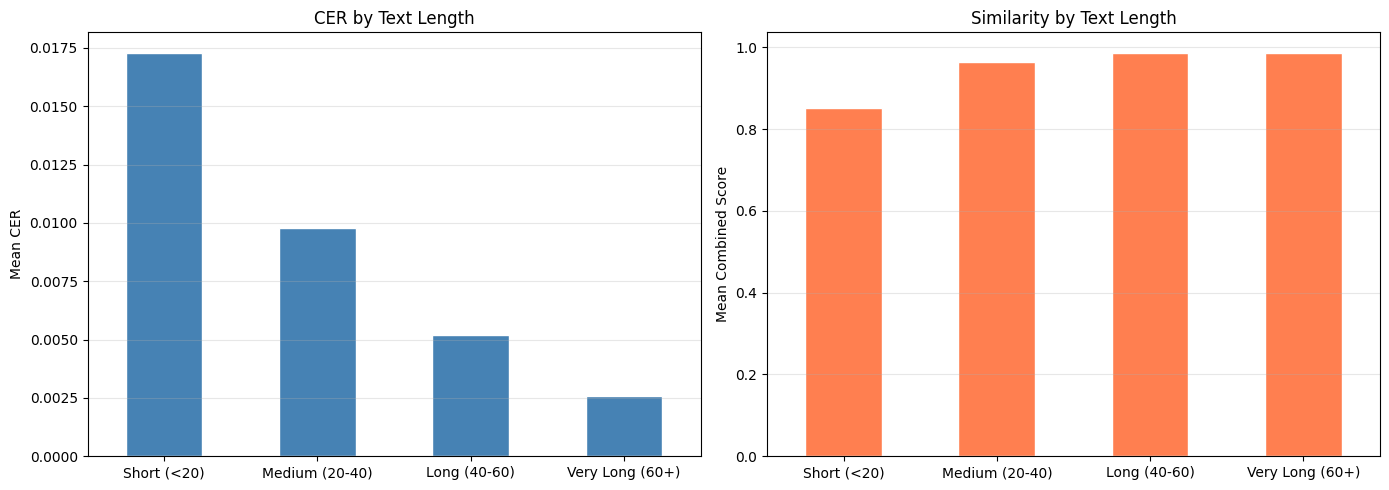

In [17]:
# Stratify by text length
df_d3['length_bin'] = pd.cut(df_d3['text_length'], bins=[0, 20, 40, 60, 200], labels=['Short (<20)', 'Medium (20-40)', 'Long (40-60)', 'Very Long (60+)'])

print('DIFFICULTY ANALYSIS: Performance by Text Length')
print('=' * 70)
grouped = df_d3.groupby('length_bin', observed=True).agg(
    count=('cer', 'count'),
    mean_cer=('cer', 'mean'),
    mean_wer=('wer', 'mean'),
    mean_combined=('combined', 'mean'),
).round(4)
print(grouped.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

grouped.plot(y='mean_cer', kind='bar', ax=axes[0], color='steelblue', edgecolor='white', legend=False)
axes[0].set_ylabel('Mean CER'); axes[0].set_title('CER by Text Length'); axes[0].set_xlabel(''); axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

grouped.plot(y='mean_combined', kind='bar', ax=axes[1], color='coral', edgecolor='white', legend=False)
axes[1].set_ylabel('Mean Combined Score'); axes[1].set_title('Similarity by Text Length'); axes[1].set_xlabel(''); axes[1].grid(axis='y', alpha=0.3)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'difficulty_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Save All Results

In [18]:
final_results = {
    'deliverable': 3,
    'd2_results': {
        'test_samples': NUM_TEST_D2,
        'mean_cer': ocr_d2['mean_cer'], 'mean_wer': ocr_d2['mean_wer'],
        'mean_combined': round(df_d2['combined'].mean(), 4),
    },
    'd3_results': {
        'test_samples': NUM_TEST_D3,
        'mean_cer': ocr_d3['mean_cer'], 'mean_wer': ocr_d3['mean_wer'],
        'mean_combined': round(df_d3['combined'].mean(), 4),
        'mean_levenshtein': round(df_d3['levenshtein'].mean(), 4),
        'mean_bleu': round(df_d3['bleu'].mean(), 4),
        'mean_cosine': round(df_d3['cosine'].mean(), 4),
    },
    'cascade_d3': {
        'good_ocr_count': cascade_d3['good_ocr']['count'],
        'poor_ocr_count': cascade_d3['poor_ocr']['count'],
        'good_combined': cascade_d3['good_ocr'].get('mean_combined'),
        'poor_combined': cascade_d3['poor_ocr'].get('mean_combined'),
    },
    'improvements': [
        'Expanded evaluation from 50 to 200 samples',
        'Added CLAHE contrast enhancement to preprocessing',
        'Added adaptive thresholding (replacing Otsu as default)',
        'Added weight sensitivity analysis',
        'Added difficulty-stratified evaluation by text length',
        'Improved Gradio UI with preprocessed image, quality assessment, confidence labels',
    ]
}

with open(os.path.join(RESULTS_DIR, 'final_results_d3.json'), 'w') as f:
    json.dump(final_results, f, indent=2)
df_d3.to_csv(os.path.join(RESULTS_DIR, 'test_results_d3.csv'), index=False)

print('All D3 results saved:')
for fname in sorted(os.listdir(RESULTS_DIR)):
    if not fname.startswith('.'): print(f'  {fname}')

All D3 results saved:
  cascade_analysis.png
  cascade_analysis_d3.png
  cer_distribution_d2_vs_d3.png
  cer_vs_similarity.png
  cer_vs_similarity_d3.png
  cer_wer_distributions.png
  correlation_d2_vs_d3.png
  difficulty_analysis.png
  final_results.json
  final_results_d3.json
  metrics_correlation.png
  preprocessing_comparison_d2_vs_d3.png
  sample_iam_image.png
  sample_images.png
  test_predictions_d3.png
  test_predictions_visual.png
  test_results.csv
  test_results_d3.csv
  text_length_distributions.png
  weight_sensitivity.png


---
## 10. Launch Improved Gradio Interface

D3 UI improvements: preprocessed image display, image quality assessment, confidence labels, better layout.

In [19]:
import gradio as gr
from src.evaluation import compute_cer, compute_wer
from src.preprocessing import pil_to_cv2, cv2_to_pil, preprocess_image, assess_image_quality

def get_confidence(score):
    if score >= 0.90: return 'High Confidence'
    elif score >= 0.70: return 'Medium Confidence'
    elif score >= 0.50: return 'Low Confidence'
    else: return 'Very Low Confidence'

def evaluate(image, ref_text, wl, wb, wc):
    if image is None: return None, 'No image.', '', '', '', '', '', '', ''
    if not ref_text or not ref_text.strip(): return None, 'Enter reference text.', '', '', '', '', '', '', ''
    try:
        pil = Image.fromarray(image).convert('RGB') if isinstance(image, np.ndarray) else image.convert('RGB')
        cv2_img = pil_to_cv2(pil)
        quality = assess_image_quality(cv2_img)
        preprocessed = cv2_to_pil(preprocess_image(cv2_img))
        quality_str = f"Contrast: {quality['contrast']} | Sharpness: {quality['sharpness']} | Intensity: {quality['mean_intensity']}"
        transcription = processor.batch_decode(model.generate(processor(images=pil, return_tensors='pt').pixel_values.to(device), max_length=128), skip_special_tokens=True)[0]
        s_cer = compute_cer(transcription, ref_text)
        s_wer = compute_wer(transcription, ref_text)
        tw = wl+wb+wc or 1.0
        sim = compute_hybrid_score(transcription, ref_text, weights={'levenshtein':wl/tw,'bleu':wb/tw,'cosine':wc/tw}, return_breakdown=True)
        conf = get_confidence(sim['combined_score'])
        return (preprocessed, transcription, f'{s_cer:.4f} ({s_cer*100:.2f}%)', f'{s_wer:.4f} ({s_wer*100:.2f}%)',
                f'{sim["levenshtein"]:.4f}', f'{sim["bleu"]:.4f}', f'{sim["cosine"]:.4f}', f'{sim["combined_score"]:.4f} — {conf}', quality_str)
    except Exception as e:
        return None, f'Error: {e}', '', '', '', '', '', '', ''

with gr.Blocks(title='ScribeCheck v2') as demo:
    gr.Markdown('# ScribeCheck v2 — Handwritten Text Evaluation\nUpload a handwritten image and enter reference text. Now with preprocessing preview and confidence scoring.')
    with gr.Row():
        with gr.Column():
            gr.Markdown('### Input')
            img_in = gr.Image(type='pil', label='Handwritten Image')
            ref_in = gr.Textbox(label='Reference Text', placeholder='Enter expected text...', lines=3)
            gr.Markdown('#### Weights')
            with gr.Row():
                wl=gr.Slider(0,1,value=0.35,step=0.05,label='Levenshtein')
                wb=gr.Slider(0,1,value=0.30,step=0.05,label='BLEU')
                wc=gr.Slider(0,1,value=0.35,step=0.05,label='Cosine')
            btn=gr.Button('Run Evaluation',variant='primary',size='lg')
        with gr.Column():
            gr.Markdown('### Results')
            pp_out=gr.Image(label='Preprocessed Image',type='pil')
            q_out=gr.Textbox(label='Image Quality',interactive=False)
            t_out=gr.Textbox(label='OCR Transcription',interactive=False)
            with gr.Row():
                cer_o=gr.Textbox(label='CER',interactive=False)
                wer_o=gr.Textbox(label='WER',interactive=False)
            gr.Markdown('#### Similarity')
            with gr.Row():
                l_o=gr.Textbox(label='Levenshtein',interactive=False)
                b_o=gr.Textbox(label='BLEU',interactive=False)
                c_o=gr.Textbox(label='Cosine',interactive=False)
            cb_o=gr.Textbox(label='Combined Score & Confidence',interactive=False)
    btn.click(fn=evaluate,inputs=[img_in,ref_in,wl,wb,wc],outputs=[pp_out,t_out,cer_o,wer_o,l_o,b_o,c_o,cb_o,q_out])
    gr.Markdown('---\n**Note:** Model trained on IAM Handwriting Database. Performance may vary on different handwriting styles.')

print('Launching ScribeCheck v2...')
demo.launch(inline=True, share=False)

Launching ScribeCheck v2...
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


---
## Summary: D2 → D3 Improvements

| Aspect | D2 | D3 |
|--------|-----|-----|
| Test samples | 50 | 200 (4x) |
| Preprocessing | Otsu binarization | CLAHE + Adaptive thresholding |
| Cascade analysis | 1 poor-OCR sample | More samples for robust analysis |
| New analyses | — | Weight sensitivity, difficulty stratification |
| Gradio UI | Basic | Preprocessed image, quality assessment, confidence labels |
| Error handling | Minimal | Try/except with informative messages |

### Remaining Limitations
- MPS training incompatibility (PyTorch issue)
- Model doesn't generalize to non-IAM handwriting
- Similarity weights are still defaults; labeled test set planned for future work